In [1]:
import os
import sys
import torch
from tqdm import tqdm
from dotenv import load_dotenv
import pandas as pd
load_dotenv()
sys.path.append(os.getenv("ROOT_PATH"))
import miso_utils.datasets as mud

In [2]:
val_data = mud.MisoValDataset(os.getenv("VAL_PATH"))
train_data = mud.MisoTrainDataset(os.getenv("TRAIN_PATH"), miso_count=2000, nmiso_count=3000)

Files Left: 600it [00:09, 65.70it/s]
Files Left: 9395it [03:14, 48.37it/s]


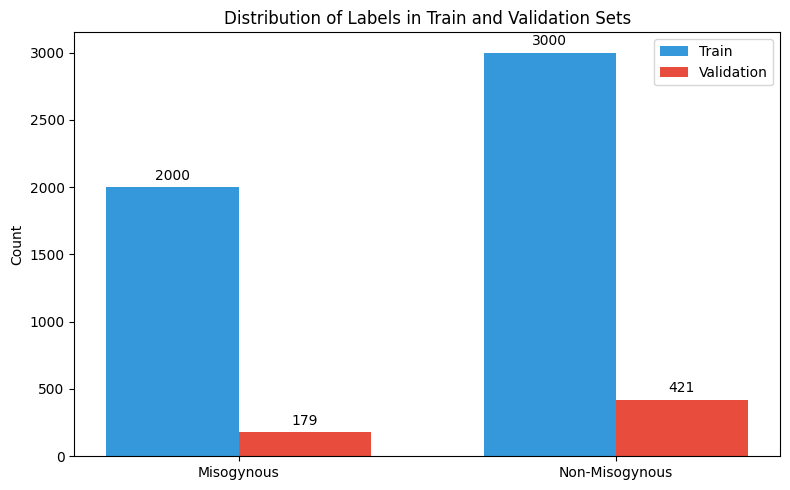

In [9]:
misoVal = 0
nmisoVal = 0

for i in range(len(val_data)):
    d = val_data.__getitem__(i)
    if d['indian_label']: misoVal+=1
    else: nmisoVal+=1

misoTrian = 0
nmisoTrain = 0

for i in range(len(train_data)):
    d = train_data.__getitem__(i)
    if d['indian_label']: misoTrian+=1
    else: nmisoTrain+=1

import matplotlib.pyplot as plt
import numpy as np

# Data from your loops
categories = ['Misogynous', 'Non-Misogynous']
train_counts = [misoTrian, nmisoTrain]
val_counts = [misoVal, nmisoVal]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

# Creating grouped bars
rects1 = ax.bar(x - width/2, train_counts, width, label='Train', color='#3498db')
rects2 = ax.bar(x + width/2, val_counts, width, label='Validation', color='#e74c3c')

# Labels and formatting
ax.set_ylabel('Count')
ax.set_title('Distribution of Labels in Train and Validation Sets')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Adding value labels on top of bars
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.tight_layout()
plt.show()


#### Indian and Chinese Label Overlap

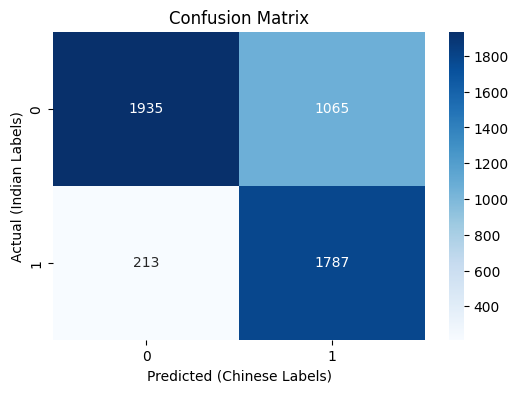

In [10]:
indian_labels = [item["indian_label"] for item in train_data]
chinese_labels = [item["chinese_label"] for item in train_data]

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
labels = sorted(list(set(indian_labels)))
cm = confusion_matrix(indian_labels, chinese_labels, labels=labels)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted (Chinese Labels)')
plt.ylabel('Actual (Indian Labels)')
plt.title('Confusion Matrix')
plt.show()

#### CNN BASELINE

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MisoCNN(nn.Module):
    def __init__(self):
        super(MisoCNN, self).__init__()
        # Input: 3 x 224 x 224
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
      
        self.fc1 = nn.Linear(64 * 28 * 28, 28 * 28)
        self.fc2 = nn.Linear(28 * 28, 256) 
        self.fc3 = nn.Linear(256,1)
        
    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 64 * 28 * 28) 
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

In [13]:
from torch.utils.data import DataLoader
import torch.optim as optim
import os

# 1. Setup Data
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

# 2. Setup Model, Loss, and Optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MisoCNN().to(device)
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 3. Training Loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for batch in tqdm(train_loader):
        # Move data to CUDA
        images = batch['img'].to(device)
        labels = batch['indian_label'].to(device).float().unsqueeze(1)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

    # 4. Basic Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            images = batch['img'].to(device)
            labels = batch['indian_label'].to(device).float().unsqueeze(1)
            outputs = model(images)
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    print(f"Validation Accuracy: {100 * correct / total:.2f}%")

100%|██████████| 79/79 [00:06<00:00, 11.55it/s]


Epoch 1/10 - Loss: 39.3678
Validation Accuracy: 70.17%


100%|██████████| 79/79 [00:06<00:00, 11.68it/s]


Epoch 2/10 - Loss: 40.2492
Validation Accuracy: 70.17%


100%|██████████| 79/79 [00:06<00:00, 11.58it/s]


...

Epoch 8/10 - Loss: 40.5261
Validation Accuracy: 70.17%


100%|██████████| 79/79 [00:06<00:00, 11.57it/s]


Epoch 9/10 - Loss: 40.1108
Validation Accuracy: 70.17%


100%|██████████| 79/79 [00:06<00:00, 11.70it/s]


Epoch 10/10 - Loss: 39.8339
Validation Accuracy: 70.17%


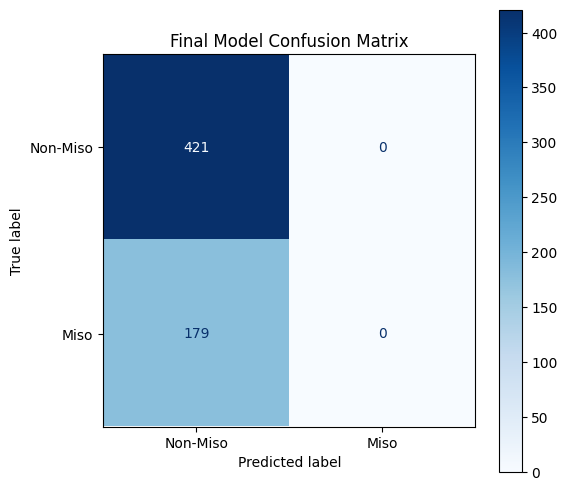

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

# 1. Collect all predictions and ground truths
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        images = batch['img'].to(device)
        labels = batch['indian_label'].to(device).float().view(-1) # Flatten
        
        outputs = model(images).view(-1)
        predictions = (outputs > 0.5).float()
        
        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Non-Miso', 'Miso'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Final Model Confusion Matrix')
plt.show()